# Setup Environment

In [17]:
# Import libraries

# Standard libraries
from pathlib import Path
import warnings

# Progress bar library
from tqdm import tqdm

# Data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Modelling and evaluation libraries
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model
from scipy.stats import t, chi2, gaussian_kde

# Bayesian libraries
import arviz as az
import pymc as pm
import pytensor.tensor as pt
from pytensor.scan import scan

# Data source
import yfinance as yf


print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
# print(f"seaborn version: {sns.__version__}")

NumPy version: 2.5.2
pandas version: 3.0.5
matplotlib version: 3.11.1


In [18]:
# Create plots and models directories if they don't exist

plots_dir     = Path("plots")
eda_plots_dir = plots_dir / "EDA"
arimax_plots_dir   = plots_dir / "arimax_garch"
bayesian_plots_dir = plots_dir / "bayesian_garch"

plots_dir.mkdir(exist_ok=True)
eda_plots_dir.mkdir(exist_ok=True)
arimax_plots_dir.mkdir(exist_ok=True)
bayesian_plots_dir.mkdir(exist_ok=True)


models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Load Data (yfinance API) and Preprocessing

In [19]:
# 1. Download historical data for S&P 500 and VIX using yfinance

# S&P 500 and VIX tickers
tickers = ["^GSPC", "^VIX"]

start_date = "2020-01-01"
end_date = "2026-01-01"

# Download the Close prices for the specified tickers and date range
print(f"Downloading data for tickers: {tickers} from {start_date} to {end_date}")
raw_data = yf.download(tickers, start=start_date, end=end_date)['Close']


[*********************100%***********************]  2 of 2 completed

In [20]:
# Handle missing values by forward filling and dropping any remaining NaN values 

data = raw_data.copy()  # Create a copy of the raw data to avoid modifying it directly

# Rename the columns for clarity
data.columns = ['SP500', 'VIX']

# use forward fill to handle missing values, then drop any remaining NaN values
data = data.ffill().dropna()

print(data.head())
print("\n--- Data Information ---")
print(data.info())

                  SP500    VIX
Date                          
2020-01-02  3257.850098  12.47
2020-01-03  3234.850098  14.02
2020-01-06  3246.280029  13.85
2020-01-07  3237.179932  13.79
2020-01-08  3253.050049  13.45

--- Data Information ---
<class 'pandas.DataFrame'>
DatetimeIndex: 1508 entries, 2020-01-02 to 2025-12-31
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SP500   1508 non-null   float64
 1   VIX     1508 non-null   float64
dtypes: float64(2)
memory usage: 35.3 KB
None


# Feature Engineering and EDA

In [21]:
# Feature Engineering: Create lagged features for S&P 500 and VIX

df = pd.DataFrame(index=data.index)

# ================================================
# S&P 500 Features
# ================================================

# S&P 500 Target (Log Return %)
df['SP500_Return'] = np.log(data['SP500'] / data['SP500'].shift(1)) * 100

# S&P 500 Squared Return
# Used for providing evidence of ARCH effect and volatility persistence in the ACF of squared returns
df['SP500_Squared_Return'] = df['SP500_Return'] ** 2


# ================================================
# VIX Exogenous Features
# ================================================

# Should not use VIX level directly as it is not stationary
df['VIX_Level'] = data['VIX']

# Should not use the change directly as it is not lagged and can introduce look-ahead bias
df['VIX_Diff'] = data['VIX'].diff()  # Daily Absolute Change
df['VIX_Return'] = (np.log(data['VIX'] / data['VIX'].shift(1)) * 100)  # Daily Percentage Change

# Lag 1 for VIX features to avoid look-ahead bias 
df['X_VIX_Diff_Lag1'] = df['VIX_Diff'].shift(1)
df['X_VIX_Return_Lag1'] = df['VIX_Return'].shift(1)

# Remove any rows with NaN values that may have been introduced by shifting
df.dropna(inplace=True)

print('Feature Engineering completed! Data shape:', df.shape)
print(df.head())

Feature Engineering completed! Data shape: (1506, 7)
            SP500_Return  SP500_Squared_Return  VIX_Level  VIX_Diff  \
Date                                                                  
2020-01-06      0.352715              0.124408      13.85     -0.17   
2020-01-07     -0.280718              0.078802      13.79     -0.06   
2020-01-08      0.489047              0.239167      13.45     -0.34   
2020-01-09      0.663321              0.439995      12.54     -0.91   
2020-01-10     -0.285926              0.081754      12.56      0.02   

            VIX_Return  X_VIX_Diff_Lag1  X_VIX_Return_Lag1  
Date                                                        
2020-01-06   -1.219965             1.55          11.715913  
2020-01-07   -0.434157            -0.17          -1.219965  
2020-01-08   -2.496460            -0.06          -0.434157  
2020-01-09   -7.005556            -0.34          -2.496460  
2020-01-10    0.159366            -0.91          -7.005556  


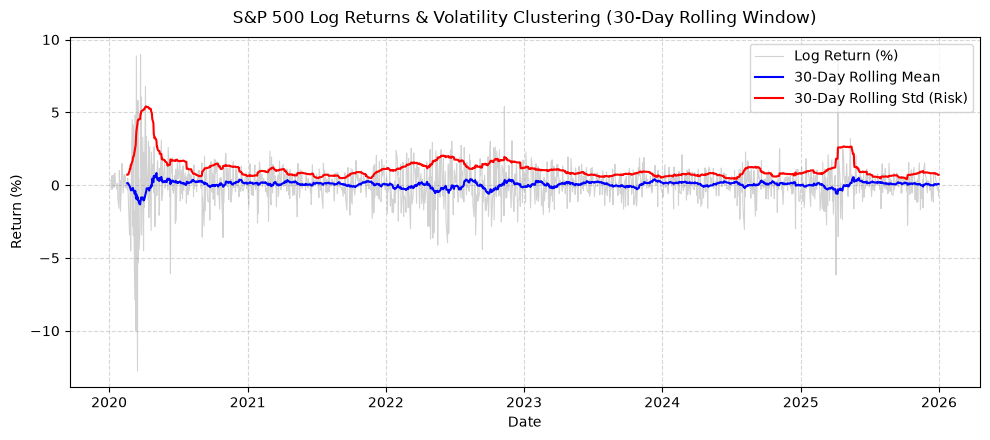

In [22]:
# Visualize Rolling Mean & Standard Deviation (Volatility Clustering)

# 30-Day Rolling Mean and Standard Deviation
roll_mean = df['SP500_Return'].rolling(window=30).mean()
roll_std = df['SP500_Return'].rolling(window=30).std()

# Plot the S&P 500 Log Returns along with the 30-day rolling mean and standard deviation
plt.figure(figsize=(10, 4.5))
plt.plot(
    df.index,
    df['SP500_Return'],
    label='Log Return (%)',
    color='gray',
    alpha=0.35,
    linewidth=0.8,
)
plt.plot(
    df.index,
    roll_mean,
    label='30-Day Rolling Mean',
    color='blue',
    linewidth=1.5,
)
plt.plot(
    df.index, roll_std, label='30-Day Rolling Std (Risk)', color='red', linewidth=1.5
)

plt.title(
    'S&P 500 Log Returns & Volatility Clustering (30-Day Rolling Window)',
    fontsize=12,
    pad=10,
)
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(eda_plots_dir / '01_rolling_mean_std.png', dpi=300)
plt.show()

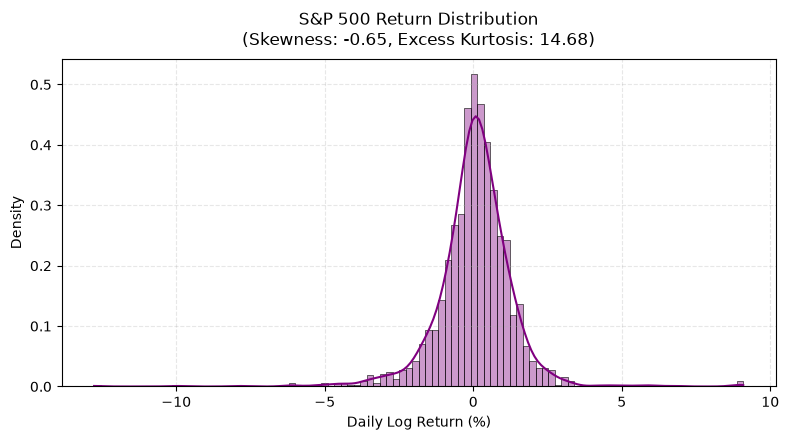

In [23]:
# Visualize the Distribution of S&P 500 Log Returns

plt.figure(figsize=(8, 4.5))

# Plot histogram and KDE
sns.histplot(
    df['SP500_Return'],
    kde=True,
    color='purple',
    bins=100,
    stat='density',
    alpha=0.4,
)

# Get the skewness and kurtosis of the S&P 500 log returns
skewness = df['SP500_Return'].skew()
kurtosis = df['SP500_Return'].kurtosis()  # Excess Kurtosis (Normal Dist = 0)

plt.title(
    f'S&P 500 Return Distribution\n(Skewness: {skewness:.2f}, Excess Kurtosis: {kurtosis:.2f})',
    fontsize=12,
    pad=10,
)
plt.xlabel('Daily Log Return (%)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(eda_plots_dir / '02_log_return_distribution.png', dpi=300)
plt.show()

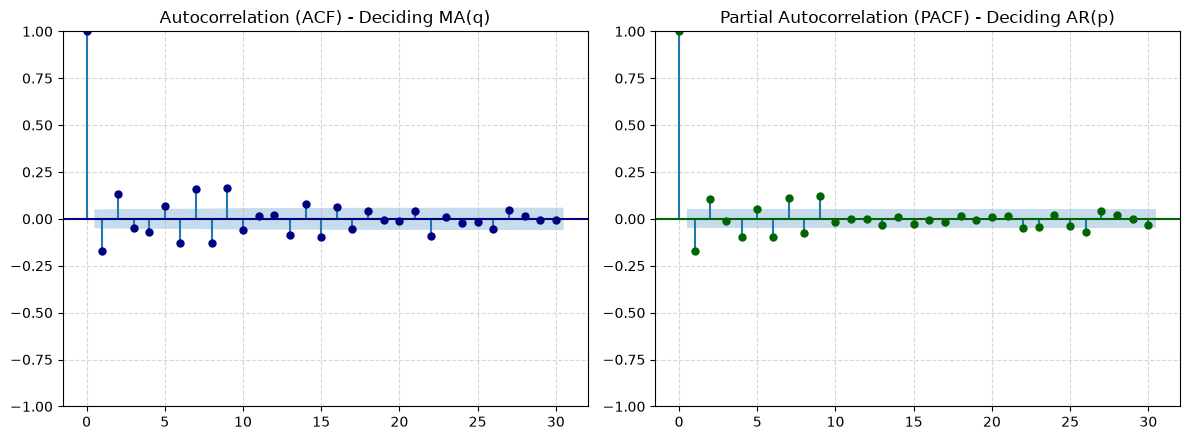

In [24]:
# Visualize ACF & PACF of Log Returns (Deciding ARIMA Order $p, q$)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ACF
plot_acf(df['SP500_Return'], ax=axes[0], lags=30, alpha=0.05, color='navy')
axes[0].set_title('Autocorrelation (ACF) - Deciding MA(q)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# PACF
plot_pacf(df['SP500_Return'], ax=axes[1], lags=30, alpha=0.05, color='darkgreen')
axes[1].set_title('Partial Autocorrelation (PACF) - Deciding AR(p)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(eda_plots_dir / '03_acf_pacf.png', dpi=300)
plt.show()

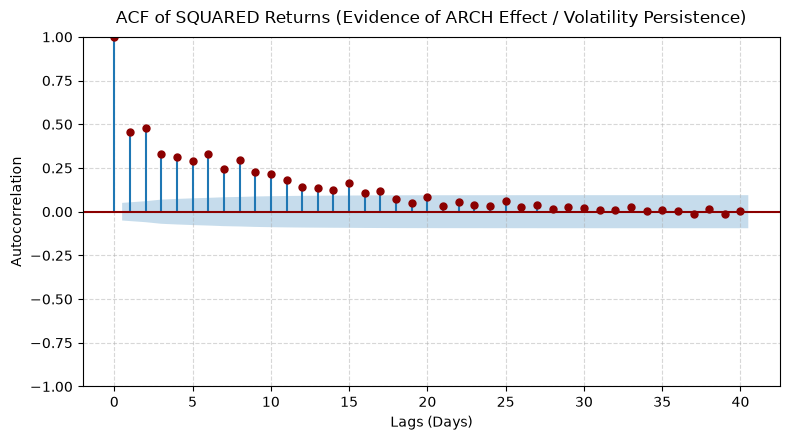

In [25]:
# Visualize ACF of Squared Returns (Evidence of ARCH Effect / Volatility Persistence)

plt.figure(figsize=(8, 4.5))
ax = plt.gca()

# Plot the ACF of Squared Returns
plot_acf(df['SP500_Squared_Return'], ax=ax, lags=40, alpha=0.05, color='darkred')

plt.title(
    'ACF of SQUARED Returns (Evidence of ARCH Effect / Volatility Persistence)',
    fontsize=12,
    pad=10,
)
plt.xlabel('Lags (Days)')
plt.ylabel('Autocorrelation')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(eda_plots_dir / '04_squared_acf.png', dpi=300)
plt.show()

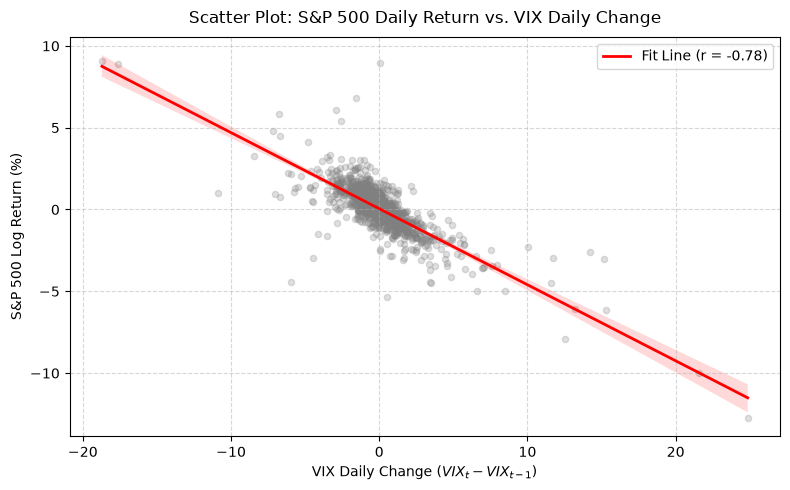

In [26]:
# Visualize the Relationship Between S&P 500 Log Returns and VIX Daily Change

# Pearson Correlation Coefficient
corr = df['SP500_Return'].corr(df['VIX_Diff'])

plt.figure(figsize=(8, 5))
sns.regplot(
    x='VIX_Diff',
    y='SP500_Return',
    data=df,
    scatter_kws={'alpha': 0.25, 'color': 'gray', 's': 20},
    line_kws={'color': 'red', 'linewidth': 2, 'label': f'Fit Line (r = {corr:.2f})'},
)

plt.title(
    f'Scatter Plot: S&P 500 Daily Return vs. VIX Daily Change',
    fontsize=12,
    pad=10,
)
plt.xlabel('VIX Daily Change ($VIX_t - VIX_{t-1}$)')
plt.ylabel('S&P 500 Log Return (%)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(eda_plots_dir / '05_vix_scatter.png', dpi=300)
plt.show()

# In-Sample Model Estimation & Diagnostics

In [27]:
# Fit the ARIMAX model to the training data

warnings.filterwarnings('ignore')

# Notes:
# ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
# This warning can be ignored as we are not using the date index for forecasting in this case. 

# Data split
y = df['SP500_Return']
exog = df[['X_VIX_Diff_Lag1']]
total_len = len(y)
train_size = int(total_len * 0.7)


# The ARIMAX model
arimax_model = SARIMAX(
    endog=y[:train_size],
    exog=exog[:train_size],
    order=(1, 0, 1),  # ARIMA(p,d,q) order
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arimax_results = arimax_model.fit()

print(arimax_results.summary())

# Notes: 
# we called the SARIMAX model but we do not use any seasonal components, 
# so it is effectively an ARIMAX model. 
# The SARIMAX class is used for both seasonal and non-seasonal models in statsmodels.

                               SARIMAX Results                                
Dep. Variable:           SP500_Return   No. Observations:                 1054
Model:               SARIMAX(1, 0, 1)   Log Likelihood               -1845.984
Date:                Thu, 13 Aug 2026   AIC                           3699.969
Time:                        05:18:24   BIC                           3719.802
Sample:                             0   HQIC                          3707.488
                               - 1054                                         
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
X_VIX_Diff_Lag1     0.0440      0.014      3.200      0.001       0.017       0.071
ar.L1              -0.4668      0.074     -6.342      0.000      -0.611      -0.323
ma.L1               0.3291      

In [28]:
# Extract the residuals from the ARIMAX model
residuals = arimax_results.resid

print("Residuals of the ARIMAX model:")
print(residuals.head())

Residuals of the ARIMAX model:
Date
2020-01-06    0.284520
2020-01-07   -0.140414
2020-01-08    0.364130
2020-01-09    0.799693
2020-01-10   -0.189666
dtype: float64


                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.001
Vol Model:                            GARCH   Log-Likelihood:               -1598.54
Distribution:      Standardized Student's t   AIC:                           3205.07
Method:                  Maximum Likelihood   BIC:                           3224.91
                                              No. Observations:                 1054
Date:                      Thu, Aug 13 2026   Df Residuals:                     1054
Time:                              05:18:24   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omeg

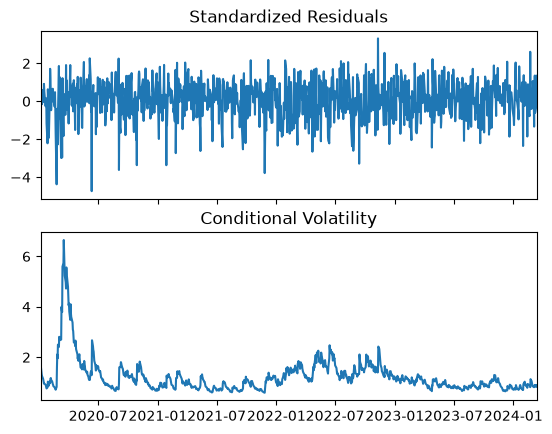

In [29]:
# Fit the GARCH model to the residuals of the ARIMAX model


garch_model = arch_model(
    residuals, 
    mean='Zero', 
    vol='GARCH', 
    p=1, 
    q=1, 
    dist='StudentsT'
)

garch_results = garch_model.fit(disp='off')

print(garch_results.summary())

fig = garch_results.plot()
plt.savefig(arimax_plots_dir / '01_garch_fit_result.png', dpi=300)
plt.show()


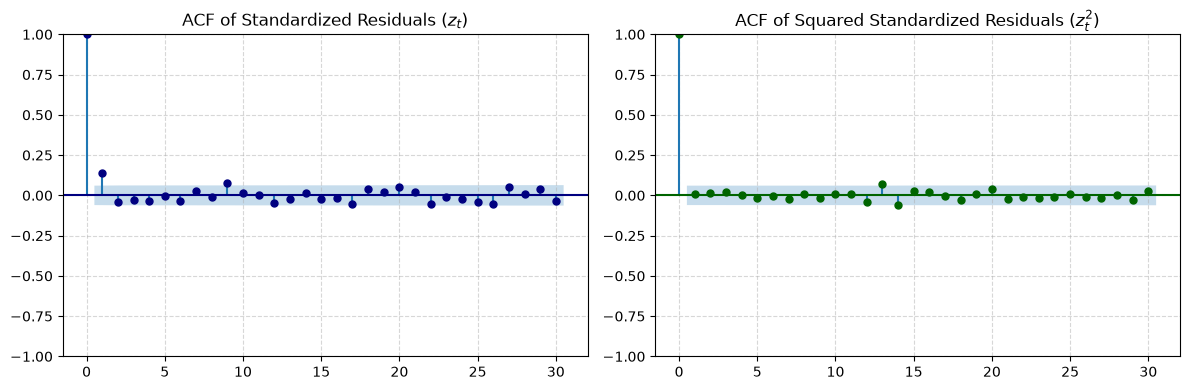

In [30]:
# Visualize the standardized residuals and their ACF/PACF

# 1. Extract standardized residuals (z_t)
std_resid = garch_results.resid / garch_results.conditional_volatility

# 2. ACF plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: ACF of z_t (Testing for remaining autocorrelation in the standardized residuals)
plot_acf(std_resid, ax=axes[0], lags=30, alpha=0.05, color='navy')
axes[0].set_title('ACF of Standardized Residuals ($z_t$)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: ACF of z_t^2 (Testing for remaining ARCH effects in the squared standardized residuals)
plot_acf(std_resid**2, ax=axes[1], lags=30, alpha=0.05, color='darkgreen')
axes[1].set_title('ACF of Squared Standardized Residuals ($z_t^2$)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(
    arimax_plots_dir / '02_garch_acf_diagnostics.png', dpi=300
)
plt.show()

In [31]:
# Save the ARIMAX and GARCH summary tables

def save_summary_as_image(summary_obj, filename):
    fig, ax = plt.subplots(figsize=(8.5, 6))
    ax.axis("off")  # Hide axes

    # Render the summary text as a monospaced font in the figure
    text = summary_obj.as_text()
    ax.text(
        0.01,
        0.99,
        text,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        fontfamily="monospace",
    )

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close()



save_summary_as_image(arimax_results.summary(), models_dir / "arimax_summary.png")
save_summary_as_image(garch_results.summary(), models_dir / "garch_summary.png")

print("Summary saved as images: arimax_summary.png and garch_summary.png")

Summary saved as images: arimax_summary.png and garch_summary.png


# Out-of-Sample Rolling Forecast & Risk Backtesting

In [32]:
# Rolling Forecast with ARIMAX-GARCH Model

# Define the forecast horizon
forecast_horizon = total_len - train_size

# Define lists to store the predicted means, predicted volatilities, and actual returns
predicted_means = []    # Store the predicted means from ARIMAX
predicted_vols  = []    # Store the predicted volatilities from GARCH
actual_returns  = []    # Store the actual returns
dates           = []    # Store the corresponding dates

for i in tqdm(range(forecast_horizon), desc="Running Rolling Forecast"):
    # Update the training data for each step in the rolling forecast
    current_idx = train_size + i
    y_train     = y.iloc[:current_idx]
    exog_train  = exog.iloc[:current_idx]

    # the actual return for the current index (used for evaluation)
    
    y_future    = y.iloc[current_idx]
    exog_future = exog.iloc[[current_idx]]
    target_date = y.index[current_idx]

    try:
        # Fit the ARIMAX model to the training data
        arimax_model = SARIMAX(
            y_train,
            exog=exog_train,
            order=(1, 0, 1),
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        arimax_result = arimax_model.fit()

        # Forecast the next step's mean using the fitted ARIMAX model
        mean_forecast = arimax_result.forecast(steps=1, exog=exog_future).iloc[0]

        # Fit the GARCH model to the residuals of the ARIMAX model
        residuals = arimax_result.resid
        garch_model = arch_model(
            residuals, mean="Zero", vol="GARCH", p=1, q=1, dist="StudentsT"
        )
        garch_result = garch_model.fit(disp="off")

        # Forecast the next step's volatility using the fitted GARCH model
        garch_forecast = garch_result.forecast(horizon=1)
        vol_forecast = np.sqrt(garch_forecast.variance.values[-1, 0])  # Get the forecasted volatility

        # Append the results to the lists
        predicted_means.append(mean_forecast)
        predicted_vols.append(vol_forecast)
        actual_returns.append(y_future)
        dates.append(target_date)

    except Exception as e:
        # Prevent the loop from stopping due to an error and log the error message
        print(f"\nError at step {i} (Date: {target_date}): {e}")
        predicted_means.append(np.nan)
        predicted_vols.append(np.nan)
        actual_returns.append(y_future)
        dates.append(target_date)


# Merge as a DataFrame for easier visualization and analysis
results_df = pd.DataFrame({
    'Predicted_Mean': predicted_means,
    'Predicted_Volatility': predicted_vols,
    'Actual_Return': actual_returns
},
    index=dates,
)

print(results_df.head())

Running Rolling Forecast: 100%|██████████| 452/452 [00:47<00:00,  9.51it/s]

            Predicted_Mean  Predicted_Volatility  Actual_Return
2024-03-14        0.061178              0.835766      -0.287522
2024-03-15        0.046287              0.798293      -0.650402
2024-03-18        0.088118              0.801899       0.629818
2024-03-19       -0.119281              0.786122       0.563325
2024-03-20       -0.062419              0.789884       0.886477


Degrees of Freedom (nu) from GARCH model: 9.9447
5th Percentile (t_quantile) for 95% VaR: -1.8135


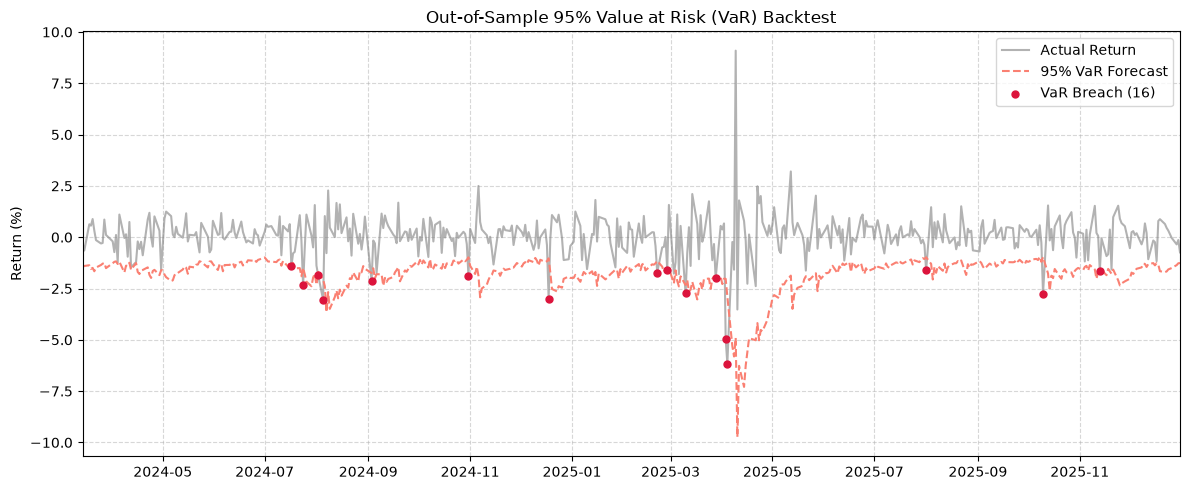

In [ ]:
# Visualize the Out-of-Sample 95% Value at Risk (VaR) Backtest

# Extract nu (degrees of freedom) from the fitted GARCH model
# 95% VaR: the 5th percentile of the Student's t-distribution with nu degrees of freedom
nu = garch_results.params['nu']
t_quantile = t.ppf(0.05, df=nu)  # 5th percentile for 95% VaR
print(f"Degrees of Freedom (nu) from GARCH model: {nu:.4f}")
print(f"5th Percentile (t_quantile) for 95% VaR: {t_quantile:.4f}")

results_df['VaR_95'] = (
    results_df['Predicted_Mean']
    + t_quantile * results_df['Predicted_Volatility']
)
results_df['Breach'] = results_df['Actual_Return'] < results_df['VaR_95']


plt.figure(figsize=(12, 5))
plt.plot(
    results_df.index,
    results_df['Actual_Return'],
    color='gray',
    alpha=0.6,
    label='Actual Return',
)
plt.plot(
    results_df.index,
    results_df['VaR_95'],
    color='salmon',
    linestyle='--',
    linewidth=1.5,
    label='95% VaR Forecast',
)

# Breaches
breaches = results_df[results_df['Breach']]

plt.scatter(
    breaches.index,
    breaches['Actual_Return'],
    color='crimson',
    s=25,
    zorder=5,
    label=f'VaR Breach ({len(breaches)})',
)

plt.title('Out-of-Sample 95% Value at Risk (VaR) Backtest', fontsize=12)
plt.ylabel('Return (%)')
plt.xlim([results_df.index[0], results_df.index[-1]])
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(arimax_plots_dir / '03_var_backtest_breaches.png', dpi=300)
plt.show()

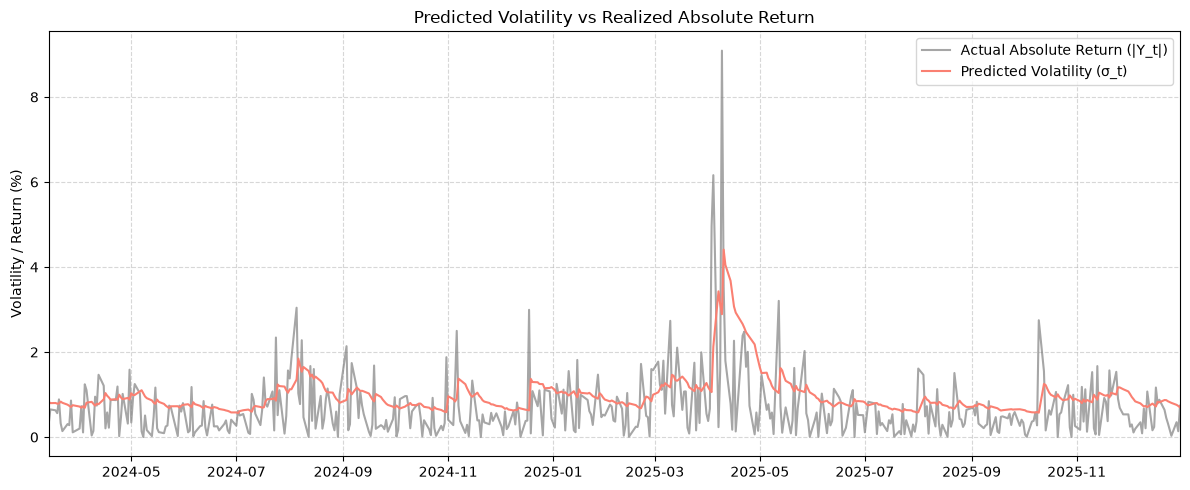

In [34]:
# Visualize the Predicted Volatility vs Realized Absolute Return

plt.figure(figsize=(12, 5))
plt.plot(
    results_df.index,
    np.abs(results_df['Actual_Return']),
    color='gray',
    alpha=0.7,
    label='Actual Absolute Return (|Y_t|)',
)
plt.plot(
    results_df.index,
    results_df['Predicted_Volatility'],
    color='salmon',
    linewidth=1.5,
    label='Predicted Volatility (σ_t)',
)

plt.title('Predicted Volatility vs Realized Absolute Return', fontsize=12)
plt.ylabel('Volatility / Return (%)')
plt.xlim([results_df.index[0], results_df.index[-1]])
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(arimax_plots_dir / '04_predicted_vs_realized_vol.png', dpi=300)
plt.show()

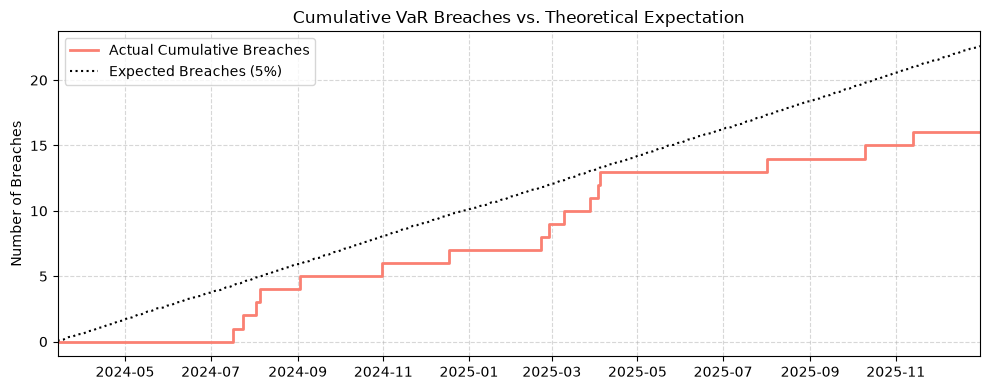

In [35]:
# Visualize the Cumulative VaR Breaches vs. Theoretical Expectation

results_df['Cumulative_Breaches'] = results_df['Breach'].cumsum()
expected_breaches = np.arange(1, len(results_df) + 1) * 0.05

plt.figure(figsize=(10, 4))
plt.plot(
    results_df.index,
    results_df['Cumulative_Breaches'],
    color='salmon',
    drawstyle='steps-post',
    linewidth=2,
    label='Actual Cumulative Breaches',
)
plt.plot(
    results_df.index,
    expected_breaches,
    color='black',
    linestyle=':',
    linewidth=1.5,
    label='Expected Breaches (5%)',
)

plt.title(
    'Cumulative VaR Breaches vs. Theoretical Expectation', fontsize=12
)
plt.ylabel('Number of Breaches')
plt.legend(loc='upper left')
plt.xlim([results_df.index[0], results_df.index[-1]])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(arimax_plots_dir / '05_cumulative_breaches.png', dpi=300)
plt.show()